# 1D Channel Capacity Analysis

This notebook demonstrates the `HdfChannelCapacity` class for analyzing 1D channel capacity
using WSE results and bank station elevations. Channel capacity is
determined by comparing water surface elevations from multiple AEP storm profiles against
bank elevations at each cross section.

**Capacity Levels:**

| Level | Category | Description |
|-------|----------|-------------|
| 1 | X ≤ 10% AEP | Only contains 10-year storm or smaller |
| 2 | 10% < X ≤ 4% | Contains up to 25-year storm |
| 3 | 4% < X ≤ 2% | Contains up to 50-year storm |
| 4 | 2% < X ≤ 1% | Contains up to 100-year storm |
| 5 | 1% < X ≤ 0.2% | Contains up to 500-year storm |
| 6 | X > 0.2% | Contains all tested storms |
| 7 | All overtop | Overtopped by smallest tested storm |

**What you'll learn:**
- Extract bank elevations from geometry HDF
- Extract individual steady-state profile WSE from a single plan HDF
- Determine channel capacity level at each cross section
- Aggregate capacity into channel segments
- Generate system-wide capacity summaries
- Compare existing vs proposed conditions

**Data Source:** FEMA BLE model (Lower Colorado-Cummins, HUC 12090301), SHILOH BRANCH reach
with 40 cross sections and 7 steady-state flow profiles.

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = True  # <-- TOGGLE THIS
import os

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path
    local_path = str(Path.cwd().parent)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print(f"LOCAL SOURCE MODE: Loading from {local_path}/ras_commander")
else:
    print("PIP PACKAGE MODE: Loading installed ras-commander")

from ras_commander import init_ras_project, RasCmdr
from ras_commander.hdf.HdfChannelCapacity import (
    HdfChannelCapacity, STORM_ORDER, LEVEL_TO_CATEGORY
)
from ras_commander.sources.federal import RasEbfeModels
import ras_commander
print(f"Loaded: {ras_commander.__file__}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

LOCAL SOURCE MODE: Loading from C:\GH\ras-commander/ras_commander


2026-04-28 23:39:23 - numexpr.utils - INFO - NumExpr defaulting to 8 threads.


Loaded: C:\GH\ras-commander\ras_commander\__init__.py


## Setup: BLE Model Preparation

We use a FEMA Base Level Engineering (BLE) reach model — SHILOH BRANCH from the Lower Colorado-Cummins study (HUC 12090301). BLE models are steady-state with 7 flow profiles representing different AEP events.

`RasEbfeModels.organize_model("lower-colorado-cummins")` handles downloading the 290.7 MB BLE archive from S3 and organizing the selected reach into the shared delivery workspace. Since BLE models were built with HEC-RAS 4.x, we re-run with HEC-RAS 6.5 to generate HDF output files needed for analysis.

**Saved-run interpretation**: 1D BLE reach projects may not include `.rasmap` files, project CRS metadata, terrain, or land-cover layers. Those warnings are expected for this 1D steady workflow and do not invalidate the HDF-based channel-capacity analysis. HDF logs may also include non-blocking metadata warnings such as unknown simulation timestamps.

In [2]:
# =============================================================================
# Parameters
# =============================================================================

# Reach to extract from BLE archive (Lower Colorado-Cummins, HUC 12090301)
BLE_RIVER = "Rabbs Creek-Colorado River"
BLE_REACH_NAME = "SHILOH BRANCH"

# HEC-RAS version for re-running (generates HDF)
RAS_VERSION = "6.5"

# BLE profile name to standard AEP mapping
# Only 5 of the 7 profiles are standard AEP events;
# '1pct_min' and '1pct_plu' are confidence bounds, excluded
BLE_TO_AEP = {
    '10-year':  '10P',   # 10% AEP
    '25-year':  '4P',    #  4% AEP  
    '50-year':  '2P',    #  2% AEP
    '100-year': '1P',    #  1% AEP
    '500-year': '0.2P',  #  0.2% AEP
}

# Storm order for capacity analysis (smallest to largest)
STORM_ORDER_BLE = ['10P', '4P', '2P', '1P', '0.2P']

# Segment length for aggregation (0.25 miles = 1320 ft)
SEGMENT_LENGTH = 1320.0

print(f"Reach: {BLE_RIVER} / {BLE_REACH_NAME}")
print(f"Storm order: {STORM_ORDER_BLE}")
# Shared eBFE workspace. Override RAS_COMMANDER_EBFE_ROOT to use a different local cache.
import tempfile
EBFE_ROOT = os.environ.get("RAS_COMMANDER_EBFE_ROOT", "")
if not EBFE_ROOT or not os.path.isdir(EBFE_ROOT):
    EBFE_ROOT = tempfile.mkdtemp(prefix="ras_ebfe_")
    print(f"RAS_COMMANDER_EBFE_ROOT not set, using temp dir: {EBFE_ROOT}")
EBFE_WORKSPACE = Path(EBFE_ROOT)
DOWNLOAD_ROOT = EBFE_WORKSPACE / "Downloads"
ORGANIZED_ROOT = EBFE_WORKSPACE / "Organized"
VALIDATION_ROOT = EBFE_WORKSPACE / "Validation" / "ebfe_delivery"
repo_candidates = [Path.cwd(), Path.cwd().parent]
VALIDATION_MATRIX = next(
    (candidate / "VALIDATION_MATRIX.md" for candidate in repo_candidates if (candidate / "VALIDATION_MATRIX.md").exists()),
    Path.cwd() / "VALIDATION_MATRIX.md",
)

print(f"eBFE workspace: {EBFE_WORKSPACE}")
print(f"Validation matrix: {VALIDATION_MATRIX}")


Reach: Rabbs Creek-Colorado River / SHILOH BRANCH
Storm order: ['10P', '4P', '2P', '1P', '0.2P']
eBFE workspace: H:\Testing\eBFE Model Organization
Validation matrix: C:\GH\ras-commander\VALIDATION_MATRIX.md


In [3]:
# Download/cache, extract, and organize the BLE model using the shared eBFE delivery workspace.
# Auto-downloads 290.7 MB from S3 if not already cached under DOWNLOAD_ROOT.
organized = RasEbfeModels.organize_model(
    "lower-colorado-cummins",
    download_root=DOWNLOAD_ROOT,
    output_root=ORGANIZED_ROOT,
    river=BLE_RIVER,
    reach=BLE_REACH_NAME,
)

# Project folder is under RAS Model/{River}/{Reach}/
project_folder = organized / "RAS Model" / BLE_RIVER / BLE_REACH_NAME

print(f"Organized to: {organized}")
print(f"Project folder: {project_folder}")
print(f"Validation root: {VALIDATION_ROOT}")
print(f"\nProject files:")
for f in sorted(project_folder.iterdir()):
    if f.is_file():
        print(f"  {f.name} ({f.stat().st_size:,} bytes)")


Organizing Lower Colorado-Cummins (12090301) - Pattern 1D-BLE
Source: H:\Testing\eBFE Model Organization\Downloads\12090301_LowerColoradoCummins
Output: H:\Testing\eBFE Model Organization\Organized\LowerColoradoCummins_12090301

Source data not found - downloading from eBFE S3...



✓ Lower Colorado-Cummins Models (290.7 MB) already downloaded: H:\Testing\eBFE Model Organization\Downloads\12090301_Models.zip
✓ Lower Colorado-Cummins Models (290.7 MB) already extracted: H:\Testing\eBFE Model Organization\Downloads\12090301_Models_extracted
[1/3] Scanning reach models...


  Found 2,332 reach models across 7 rivers
  Filtered to: 1 reach(es)

[2/3] Organizing reach models...
  Organized 1 reach(es), 8 files total

[3/3] Creating model log...

✓ Lower Colorado-Cummins organized to: H:\Testing\eBFE Model Organization\Organized\LowerColoradoCummins_12090301
  River: Rabbs Creek-Colorado River, Reach: SHILOH BRANCH
  Reaches: 1 of 2,332
  Files: 8
Organized to: H:\Testing\eBFE Model Organization\Organized\LowerColoradoCummins_12090301
Project folder: H:\Testing\eBFE Model Organization\Organized\LowerColoradoCummins_12090301\RAS Model\Rabbs Creek-Colorado River\SHILOH BRANCH
Validation root: H:\Testing\eBFE Model Organization\Validation\ebfe_delivery

Project files:
  SHILOH BRANCH.f01 (1,778 bytes)
  SHILOH BRANCH.g01 (358,968 bytes)
  SHILOH BRANCH.O01 (224,000 bytes)
  SHILOH BRANCH.p01 (3,197 bytes)
  SHILOH BRANCH.p01.comp_msgs.txt (122 bytes)
  SHILOH BRANCH.p01.hdf (735,637 bytes)
  SHILOH BRANCH.prj (591 bytes)
  SHILOH BRANCH.r01 (255,091 bytes)
  SH

In [4]:
# Initialize project
ras = init_ras_project(project_folder, RAS_VERSION)

print(f"Project: {ras.project_name}")
print(f"Plans: {len(ras.plan_df)}")
print(f"Geometry: {ras.geom_df['geom_title'].iloc[0]}")
print(f"Flow profiles: {ras.flow_df['Flow Title'].iloc[0]}")

# BLE models were built with HEC-RAS 4.x — update plan to 6.x format
# so that HEC-RAS 6.5 generates HDF output files
plan_file = project_folder / f"{ras.project_name}.p01"
plan_text = plan_file.read_text()
plan_text = plan_text.replace("Program Version=4.10", f"Program Version={RAS_VERSION}0")
plan_text = plan_text.replace("Run HTab= 0", "Run HTab= 1")
plan_text = plan_text.replace("Run PostProcess= 0", "Run PostProcess= 1")
plan_file.write_text(plan_text)
print(f"\nUpdated plan to HEC-RAS {RAS_VERSION} format (enables HDF output)")

# Run the plan with geometry preprocessing to generate HDF
print("Running HEC-RAS...")
RasCmdr.compute_plan("01", ras_object=ras, force_geompre=True)

# Re-initialize to pick up HDF paths
ras = init_ras_project(project_folder, RAS_VERSION)

# Verify HDF files created
hdf_files = list(project_folder.glob("*.hdf"))
print(f"\nHDF files generated:")
for h in hdf_files:
    print(f"  {h.name} ({h.stat().st_size:,} bytes)")

2026-04-28 23:39:35 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-04-28 23:39:35 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-04-28 23:39:35 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 4 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 4\Ras.exe via filesystem (x86)


2026-04-28 23:39:35 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


2026-04-28 23:39:35 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.4.1 at C:\Program Files (x86)\HEC\HEC-RAS\6.4.1\Ras.exe via filesystem (x86)


...

2026-04-28 23:39:41 - ras_commander.RasPrj - INFO - Updated results_df with 1 plan(s)


2026-04-28 23:39:41 - ras_commander.RasPrj - INFO - ras-commander v0.94.0 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-04-28 23:39:41 - ras_commander.RasPrj - INFO - Project initialized: SHILOH BRANCH | Folder: H:\Testing\eBFE Model Organization\Organized\LowerColoradoCummins_12090301\RAS Model\Rabbs Creek-Colorado River\SHILOH BRANCH


2026-04-28 23:39:41 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe



HDF files generated:
  SHILOH BRANCH.g01.hdf (332,515 bytes)
  SHILOH BRANCH.p01.hdf (735,637 bytes)


## Step 1: Extract Bank Elevations

`extract_bank_elevations()` reads cross section geometry from the geometry HDF
and interpolates elevations at the left and right bank stations. The "controlling"
bank elevation (the higher of the two) determines where overtopping occurs.

In [5]:
# Get geometry HDF path
geom_hdf = project_folder / f"{ras.project_name}.g01.hdf"

bank_df = HdfChannelCapacity.extract_bank_elevations(str(geom_hdf))

print(f"Cross sections: {len(bank_df)}")
print(f"\nBank elevation range:")
print(f"  Left:  {bank_df['left_bank_elev'].min():.1f} - {bank_df['left_bank_elev'].max():.1f} ft")
print(f"  Right: {bank_df['right_bank_elev'].min():.1f} - {bank_df['right_bank_elev'].max():.1f} ft")
print(f"  Controlling: {bank_df['controlling_bank_elev'].min():.1f} - {bank_df['controlling_bank_elev'].max():.1f} ft")

bank_df.head(10)

2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO - Extracting bank elevations from: SHILOH BRANCH.g01.hdf


2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO - Extracted bank elevations for 40 cross sections


Cross sections: 40

Bank elevation range:
  Left:  251.7 - 337.6 ft
  Right: 251.6 - 337.0 ft
  Controlling: 251.7 - 337.6 ft


,River,Reach,RS,Left Bank,Right Bank,left_bank_elev,right_bank_elev,controlling_bank_elev,Len Channel
0,SHILOH BRANCH,Reach-1,25147,4952.600098,5352.399902,337.649994,337.019989,337.649994,418.0
1,SHILOH BRANCH,Reach-1,24729,4725.000000,5036.299805,336.500000,335.700012,336.500000,614.0
2,SHILOH BRANCH,Reach-1,24115,4802.799805,5104.299805,334.750000,334.429993,334.750000,534.0
3,SHILOH BRANCH,Reach-1,23581,4924.399902,5204.500000,332.399994,332.440002,332.440002,795.0
4,SHILOH BRANCH,Reach-1,22786,4835.700195,5135.700195,328.369995,328.739990,328.739990,553.0
5,SHILOH BRANCH,Reach-1,22233,4796.100098,5056.100098,325.679993,325.679993,325.679993,877.0
6,SHILOH BRANCH,Reach-1,21356,4946.299805,5176.399902,321.619995,320.619995,321.619995,148.0
7,SHILOH BRANCH,Reach-1,21208,4944.799805,5225.100098,320.029999,319.970001,320.029999,1494.0
8,SHILOH BRANCH,Reach-1,19714,4835.000000,5080.500000,313.519989,313.190002,313.519989,456.0
9,SHILOH BRANCH,Reach-1,19258,4938.700195,5108.600098,310.529999,310.820007,310.820007,320.0


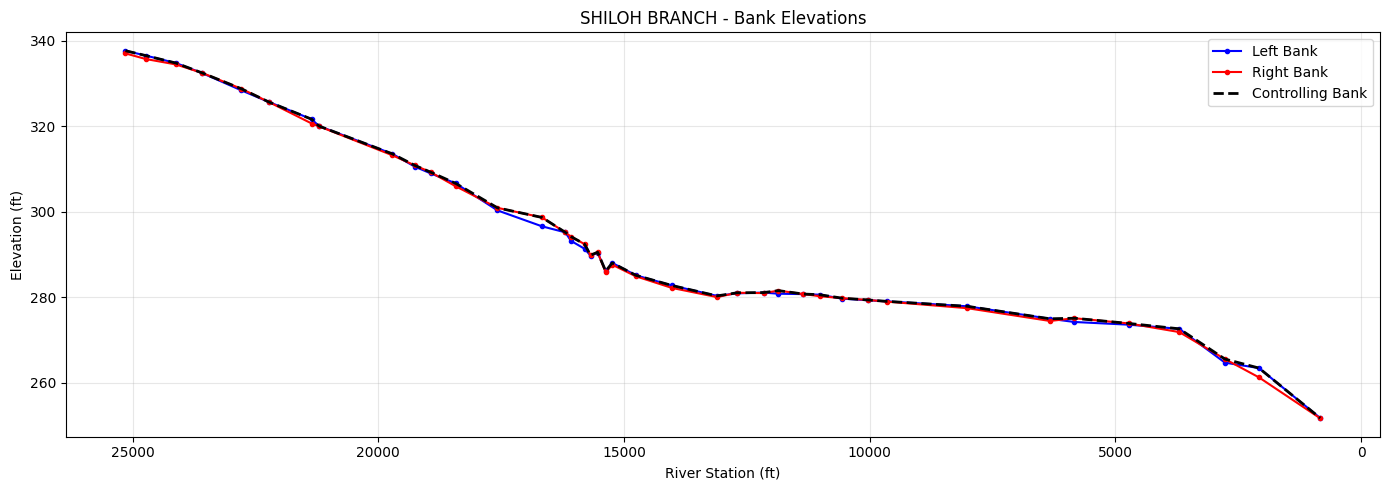

In [6]:
# Plot bank elevations along the channel
fig, ax = plt.subplots(figsize=(14, 5))

rs_float = bank_df['RS'].astype(float)

ax.plot(rs_float, bank_df['left_bank_elev'], 'b-o', markersize=3, label='Left Bank')
ax.plot(rs_float, bank_df['right_bank_elev'], 'r-o', markersize=3, label='Right Bank')
ax.plot(rs_float, bank_df['controlling_bank_elev'], 'k--', linewidth=2, label='Controlling Bank')

ax.set_xlabel('River Station (ft)')
ax.set_ylabel('Elevation (ft)')
ax.set_title(f'{BLE_REACH_NAME} - Bank Elevations')
ax.legend()
ax.invert_xaxis()  # Downstream to right
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 2: Extract Steady-State Profile WSE

`extract_steady_profile_wse()` reads individual steady-state profiles from a single
plan HDF. Unlike `extract_max_wse()` (which collapses profiles to max), this method
preserves each profile as a separate column — essential for capacity analysis.

The BLE model has 7 profiles. We map 5 standard AEP events 

In [7]:
# Extract all steady-state profiles from the plan HDF
plan_hdf = project_folder / f"{ras.project_name}.p01.hdf"

all_profiles = HdfChannelCapacity.extract_steady_profile_wse(str(plan_hdf))

print(f"Profiles found: {[c for c in all_profiles.columns if c not in ('River','Reach','RS')]}")
print(f"Cross sections: {len(all_profiles)}")

# Rename BLE profile names to AEP labels and select standard events
wse_df = all_profiles.rename(columns=BLE_TO_AEP)
keep_cols = ['River', 'Reach', 'RS'] + STORM_ORDER_BLE
wse_df = wse_df[keep_cols]

print(f"\nSelected AEP profiles: {STORM_ORDER_BLE}")
print(f"Excluded: 1pct_min, 1pct_plu (confidence bounds)")

wse_df.head(10)

2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO - Extracting steady-state profiles from: SHILOH BRANCH.p01.hdf


2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO - Extracted 7 steady profiles for 40 cross sections from SHILOH BRANCH.p01.hdf


Profiles found: ['10-year', '25-year', '50-year', '1pct_min', '100-year', '1pct_plu', '500-year']
Cross sections: 40

Selected AEP profiles: ['10P', '4P', '2P', '1P', '0.2P']
Excluded: 1pct_min, 1pct_plu (confidence bounds)


,River,Reach,RS,10P,4P,2P,1P,0.2P
0,SHILOH BRANCH,Reach-1,25147,336.810333,337.419373,337.794678,338.118896,338.828705
1,SHILOH BRANCH,Reach-1,24729,335.793335,336.329254,336.679382,337.006317,337.750946
2,SHILOH BRANCH,Reach-1,24115,334.307800,334.842651,335.201111,335.512787,336.206757
3,SHILOH BRANCH,Reach-1,23581,332.265320,332.958618,333.370911,333.735413,334.437775
4,SHILOH BRANCH,Reach-1,22786,328.416779,329.410492,330.002197,330.583191,331.499481
5,SHILOH BRANCH,Reach-1,22233,325.059509,326.057037,326.748352,327.410858,328.621094
6,SHILOH BRANCH,Reach-1,21356,320.570374,321.126007,321.525146,321.919586,322.848328
7,SHILOH BRANCH,Reach-1,21208,320.034058,320.552795,320.937317,321.326630,322.259430
8,SHILOH BRANCH,Reach-1,19714,313.355347,314.021790,314.507141,314.986694,316.105804
9,SHILOH BRANCH,Reach-1,19258,309.747681,310.444519,310.884460,311.308594,312.275543


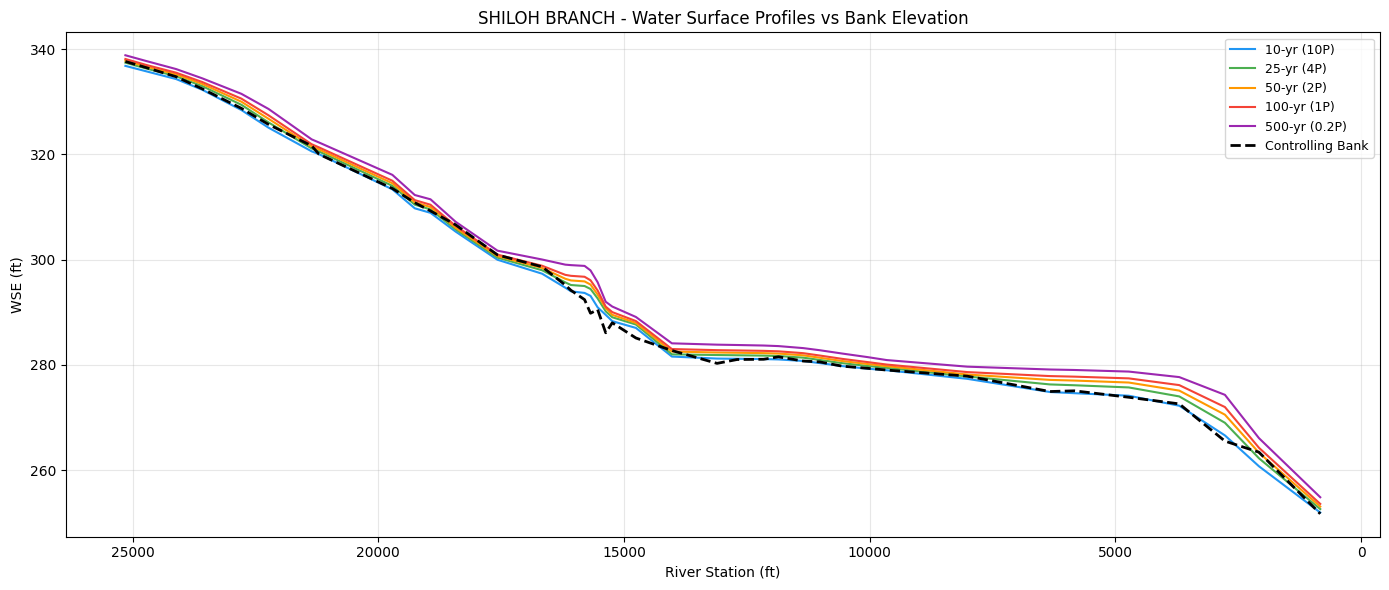

In [8]:
# Plot WSE profiles with controlling bank elevation
fig, ax = plt.subplots(figsize=(14, 6))

rs_float = wse_df['RS'].astype(float)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
labels = ['10-yr (10P)', '25-yr (4P)', '50-yr (2P)', '100-yr (1P)', '500-yr (0.2P)']

for storm, color, label in zip(STORM_ORDER_BLE, colors, labels):
    ax.plot(rs_float, wse_df[storm], color=color, linewidth=1.5, label=label)

# Overlay controlling bank elevation
bank_rs = bank_df['RS'].astype(float)
ax.plot(bank_rs, bank_df['controlling_bank_elev'], 'k--', linewidth=2, label='Controlling Bank')

ax.set_xlabel('River Station (ft)')
ax.set_ylabel('WSE (ft)')
ax.set_title(f'{BLE_REACH_NAME} - Water Surface Profiles vs Bank Elevation')
ax.legend(loc='upper right', fontsize=9)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3: Determine Channel Capacity

`determine_capacity()` tests storms from smallest (10P) to largest (0.2P) at each
cross section. The capacity level is the largest storm the channel can contain
without the WSE exceeding the controlling bank elevation.

In [9]:
capacity_df = HdfChannelCapacity.determine_capacity(
    bank_df, wse_df, storm_order=STORM_ORDER_BLE
)

print(f"Cross sections analyzed: {len(capacity_df)}")
print(f"\nCapacity distribution:")
for level in sorted(capacity_df['capacity_level'].unique()):
    count = (capacity_df['capacity_level'] == level).sum()
    category = LEVEL_TO_CATEGORY.get(level, 'Unknown')
    print(f"  Level {level} ({category}): {count} XS")

capacity_df[['RS', 'controlling_bank_elev', 'capacity_level', 
             'capacity_category', 'last_contained_storm']].head(15)

2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO -   Level 1 (X <= 10%): 15 XS


2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO -   Level 2 (10% < X <= 4%): 4 XS


2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO -   Level 3 (4% < X <= 2%): 5 XS


2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO -   Level 4 (2% < X <= 1%): 1 XS


2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO -   Level 7 (All overtop): 15 XS


Cross sections analyzed: 40

Capacity distribution:
  Level 1 (X <= 10%): 15 XS
  Level 2 (10% < X <= 4%): 4 XS
  Level 3 (4% < X <= 2%): 5 XS
  Level 4 (2% < X <= 1%): 1 XS
  Level 7 (All overtop): 15 XS


,RS,controlling_bank_elev,capacity_level,capacity_category,last_contained_storm
0,25147,337.649994,2,10% < X <= 4%,4P
1,24729,336.500000,2,10% < X <= 4%,4P
2,24115,334.750000,1,X <= 10%,10P
3,23581,332.440002,1,X <= 10%,10P
4,22786,328.739990,1,X <= 10%,10P
5,22233,325.679993,1,X <= 10%,10P
6,21356,321.619995,3,4% < X <= 2%,2P
7,21208,320.029999,7,All overtop,None
8,19714,313.519989,1,X <= 10%,10P
9,19258,310.820007,2,10% < X <= 4%,4P


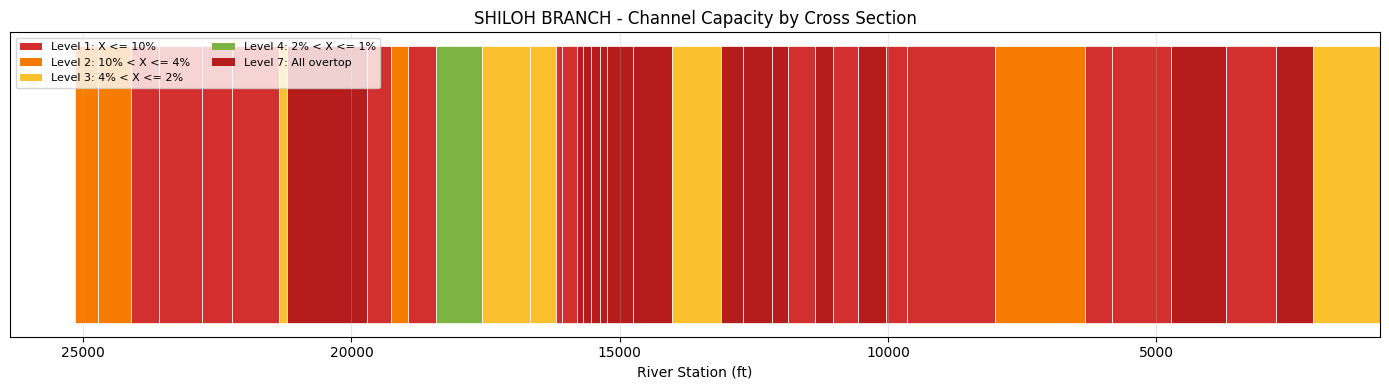

In [10]:
# Color-coded capacity level along the channel
fig, ax = plt.subplots(figsize=(14, 4))

rs_float = capacity_df['RS'].astype(float)
levels = capacity_df['capacity_level'].values

# Color map: green (good capacity) to red (poor capacity)
capacity_colors = {
    1: '#D32F2F',  # Red - poor
    2: '#F57C00',  # Orange
    3: '#FBC02D',  # Yellow
    4: '#7CB342',  # Light green
    5: '#388E3C',  # Green
    6: '#1B5E20',  # Dark green - excellent
    7: '#B71C1C',  # Dark red - worst
}

for i in range(len(rs_float) - 1):
    color = capacity_colors.get(levels[i], '#888888')
    ax.barh(0, rs_float.iloc[i] - rs_float.iloc[i+1], 
            left=rs_float.iloc[i+1], height=0.8, color=color, edgecolor='white', linewidth=0.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=capacity_colors[lv], label=f'Level {lv}: {LEVEL_TO_CATEGORY[lv]}')
    for lv in sorted(capacity_colors.keys()) if lv in levels
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8, ncol=2)

ax.set_xlabel('River Station (ft)')
ax.set_title(f'{BLE_REACH_NAME} - Channel Capacity by Cross Section')
ax.set_yticks([])
ax.invert_xaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Step 4: Segment Aggregation

`segment_channel()` groups cross sections into fixed-length segments (default: 0.25 mi)
and computes a weighted average capacity for each segment. The capacity is rounded DOWN
(conservative) to ensure the weakest areas in a segment are not masked.

In [11]:
segments_df = HdfChannelCapacity.segment_channel(
    capacity_df, segment_length=SEGMENT_LENGTH
)

print(f"Segments created: {len(segments_df)}")
print(f"Segment length: {SEGMENT_LENGTH:.0f} ft ({SEGMENT_LENGTH/5280:.2f} mi)")

segments_df

2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO - Created 17 segments across 1 reaches


Segments created: 17
Segment length: 1320 ft (0.25 mi)


,River,Reach,segment_id,segment_start_rs,segment_end_rs,weighted_capacity,capacity_level,capacity_category,channel_length,xs_count
0,SHILOH BRANCH,Reach-1,1,25147,24729,2.00,2,10% < X <= 4%,1032.0,2
1,SHILOH BRANCH,Reach-1,2,24115,23581,1.00,1,X <= 10%,1329.0,2
2,SHILOH BRANCH,Reach-1,3,22786,21356,1.19,1,X <= 10%,1578.0,3
3,SHILOH BRANCH,Reach-1,5,21208,19258,5.09,5,1% < X <= 0.2%,2270.0,3
4,SHILOH BRANCH,Reach-1,6,18938,18427,2.88,2,10% < X <= 4%,1363.0,2
5,SHILOH BRANCH,Reach-1,7,17575,16195,2.85,2,10% < X <= 4%,1495.0,3
6,SHILOH BRANCH,Reach-1,8,16080,15239,5.74,5,1% < X <= 0.2%,1322.0,6
7,SHILOH BRANCH,Reach-1,9,14758,14758,7.00,7,All overtop,732.0,1
8,SHILOH BRANCH,Reach-1,10,14026,12700,5.03,5,1% < X <= 0.2%,1867.0,3
9,SHILOH BRANCH,Reach-1,11,12159,11353,4.35,4,2% < X <= 1%,1140.0,3


In [12]:
summary_df = HdfChannelCapacity.system_capacity_summary(capacity_df)

print(f"Total channel length: {summary_df['channel_length_ft'].sum():,.0f} ft ")
print(f"                    = {summary_df['channel_length_ft'].sum()/5280:.2f} mi")
print()
summary_df

2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO - System Capacity Summary:


2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO -   Level 1 (X <= 10%): 9639 ft (39.6%)


2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO -   Level 2 (10% < X <= 4%): 3034 ft (12.5%)


2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO -   Level 3 (4% < X <= 2%): 3694 ft (15.2%)


2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO -   Level 4 (2% < X <= 1%): 852 ft (3.5%)


2026-04-28 23:39:41 - ras_commander.hdf.HdfChannelCapacity - INFO -   Level 7 (All overtop): 7096 ft (29.2%)


Total channel length: 24,315 ft 
                    = 4.61 mi



,capacity_level,capacity_category,channel_length_ft,percent_of_total,xs_count
0,1,X <= 10%,9639.0,39.6,15
1,2,10% < X <= 4%,3034.0,12.5,4
2,3,4% < X <= 2%,3694.0,15.2,5
3,4,2% < X <= 1%,852.0,3.5,1
4,5,1% < X <= 0.2%,0.0,0.0,0
5,6,X > 0.2%,0.0,0.0,0
6,7,All overtop,7096.0,29.2,15


## Key Takeaways

1. **`extract_bank_elevations()`** reads bank station elevations from the geometry HDF using `np.interp()` on station-elevation data.
2. **`extract_steady_profile_wse()`** extracts individual steady-state profiles from a single plan HDF, preserving each AEP event as a separate column.
3. **`determine_capacity()`** tests storms from smallest to largest, classifying each cross section into capacity levels 1-7.
4. **`segment_channel()`** aggregates XS-level capacity into fixed-length segments with conservative (FLOOR) weighting.
5. **`system_capacity_summary()`** produces the capacity distribution.

**Validation notes**:
- This 1D steady reach does not rely on terrain or land-cover layers for the channel-capacity workflow.
- Missing `.rasmap`/CRS warnings are expected for this older BLE reach and are surfaced in the saved output.
- `HdfResultsPlan` may emit `ERROR`-level timestamp parsing logs when older steady HDF metadata stores simulation time as `Unknown`; the HEC-RAS run and profile extraction still complete successfully.
- The important evidence is that HEC-RAS runs the steady plan, produces geometry/result HDF files, and the profile WSE extraction returns coherent cross-section results.

**For BLE models** with a single plan and multiple steady profiles, use `extract_steady_profile_wse()` instead of `extract_max_wse()` (which is designed for multi-plan workflows where each AEP is a separate plan HDF).

**References:**
- FEMA BLE program: https://www.fema.gov/flood-maps/products-tools/base-level-engineering